# 🧠 Week 6 Assessment

# **Image Denoising using Convolutional Autoencoder (MNIST)**

---

## 📌 Objective

The objective of this project is to build a **Convolutional Denoising Autoencoder** capable of removing artificial Gaussian noise from handwritten digit images in the **MNIST dataset**. The model is trained using noisy images as input and their corresponding clean images as target outputs. After training, the autoencoder learns meaningful image representations and reconstructs denoised images while preserving the original digit structure.

---

## 🎯 Project Goals

- Load and preprocess the MNIST dataset.
- Add Gaussian noise to the original images.
- Design and implement a Convolutional Denoising Autoencoder.
- Train the model using noisy images as input and clean images as targets.
- Generate denoised images from the noisy test set.
- Compare original, noisy, and reconstructed images.
- Analyze the denoising performance of the model.

---

## 🛠️ Technologies Used

- Python
- TensorFlow / Keras
- NumPy
- Matplotlib
- Jupyter Notebook

---

## 📂 Dataset

**Dataset:** MNIST Handwritten Digits

- Training Images: **60,000**
- Test Images: **10,000**
- Image Size: **28 × 28 pixels**
- Number of Classes: **10 (Digits 0–9)**

---

## 🧩 Deep Learning Concept

A **Denoising Autoencoder** is an unsupervised neural network that learns to reconstruct clean images from noisy inputs. It consists of:

- **Encoder** – Compresses the noisy input image into a latent representation.
- **Bottleneck** – Stores the compressed features.
- **Decoder** – Reconstructs the clean image from the latent representation.

The network minimizes the reconstruction error between the predicted image and the original clean image during training.

---

## 📌 Problem Statement
A denoising autoencoder learns to remove artificial noise from images by compressing them into a latent representation and reconstructing the clean image.

## 🔄 Workflow
```text
MNIST Dataset
      │
      ▼
Normalize Images
      │
      ▼
Add Gaussian Noise
      │
      ▼
Encoder
      │
      ▼
Latent Space
      │
      ▼
Decoder
      │
      ▼
Denoised Image
```

## 📚 Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input,Conv2D,MaxPooling2D,UpSampling2D
from tensorflow.keras.models import Model

## 📥 Load and Preprocess MNIST
Normalize pixel values to [0,1] and reshape images to (28,28,1).

In [2]:
(x_train,_),(x_test,_)=mnist.load_data()
x_train=x_train.astype('float32')/255.
x_test=x_test.astype('float32')/255.
x_train=x_train.reshape((-1,28,28,1))
x_test=x_test.reshape((-1,28,28,1))
print(x_train.shape,x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1) (10000, 28, 28, 1)


## 🎲 Add Gaussian Noise

In [3]:
noise_factor=0.5
x_train_noisy=np.clip(x_train+noise_factor*np.random.normal(size=x_train.shape),0.,1.)
x_test_noisy=np.clip(x_test+noise_factor*np.random.normal(size=x_test.shape),0.,1.)

## 🖼️ Visualize Original vs Noisy Images

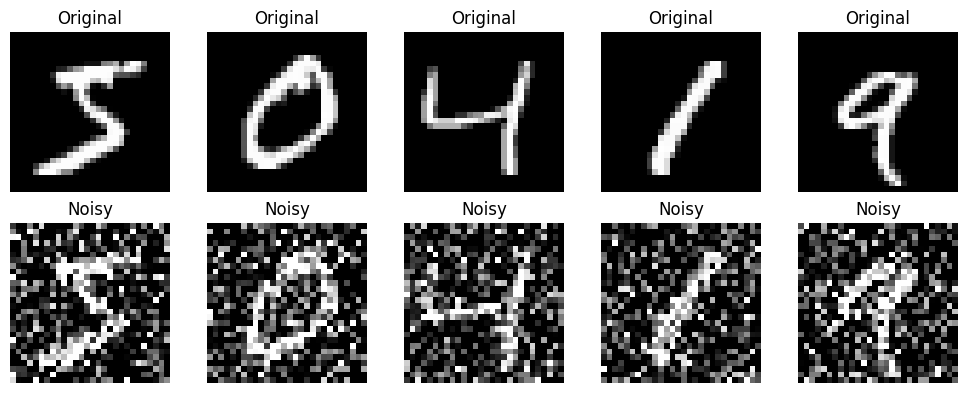

In [4]:
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(2,5,i+1);plt.imshow(x_train[i].squeeze(),cmap='gray');plt.axis('off');plt.title('Original')
    plt.subplot(2,5,i+6);plt.imshow(x_train_noisy[i].squeeze(),cmap='gray');plt.axis('off');plt.title('Noisy')
plt.tight_layout();plt.show()

## 🏗️ Model Architecture
```text
Input (28×28×1)
      │
Conv2D → MaxPooling
      │
Conv2D → MaxPooling
      │
  Bottleneck
      │
Conv2D → UpSampling
      │
Conv2D → UpSampling
      │
Output (28×28×1)
```

In [5]:
inp=Input((28,28,1))
x=Conv2D(32,3,activation='relu',padding='same')(inp)
x=MaxPooling2D(2,padding='same')(x)
x=Conv2D(32,3,activation='relu',padding='same')(x)
x=MaxPooling2D(2,padding='same')(x)
x=Conv2D(32,3,activation='relu',padding='same')(x)
x=UpSampling2D(2)(x)
x=Conv2D(32,3,activation='relu',padding='same')(x)
x=UpSampling2D(2)(x)
out=Conv2D(1,3,activation='sigmoid',padding='same')(x)
autoencoder=Model(inp,out)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## ⚙️ Compile and Train

In [6]:
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
history=autoencoder.fit(x_train_noisy,x_train,epochs=10,batch_size=128,
validation_data=(x_test_noisy,x_test))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 123s 258ms/step - loss: 0.1704 - val_loss: 0.1189
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 253ms/step - loss: 0.1142 - val_loss: 0.1092
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 253ms/step - loss: 0.1079 - val_loss: 0.1046
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 128s 274ms/step - loss: 0.1048 - val_loss: 0.1024
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 119s 254ms/step - loss: 0.1030 - val_loss: 0.1013
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 118s 252ms/step - loss: 0.1017 - val_loss: 0.0999
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 119s 255ms/step - loss: 0.1006 - val_loss: 0.0992
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 256ms/step - loss: 0.0999 - val_loss: 0.0984
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 117s 249ms/step - loss: 0.0991 - val_loss: 0.0980
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 253ms/step - loss: 0.0985 - val_loss: 0.0976


## 📉 Training Curve

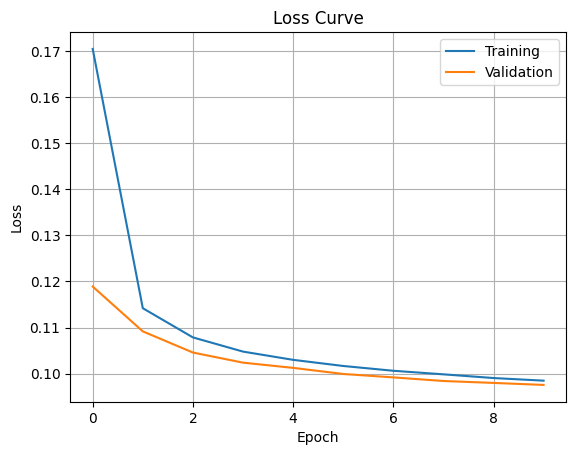

In [7]:
plt.plot(history.history['loss'],label='Training')
plt.plot(history.history['val_loss'],label='Validation')
plt.xlabel('Epoch');plt.ylabel('Loss');plt.title('Loss Curve')
plt.legend();plt.grid();plt.show()

## ✨ Generate Denoised Images

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


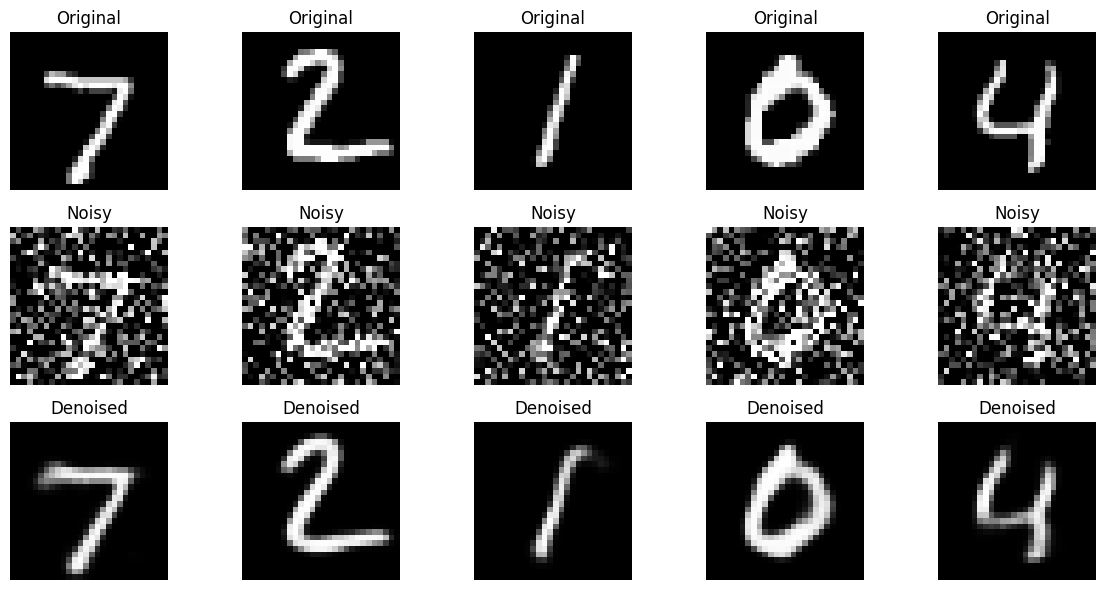

In [8]:
decoded=autoencoder.predict(x_test_noisy)
plt.figure(figsize=(12,6))
for i in range(5):
    plt.subplot(3,5,i+1);plt.imshow(x_test[i].squeeze(),cmap='gray');plt.axis('off');plt.title('Original')
    plt.subplot(3,5,i+6);plt.imshow(x_test_noisy[i].squeeze(),cmap='gray');plt.axis('off');plt.title('Noisy')
    plt.subplot(3,5,i+11);plt.imshow(decoded[i].squeeze(),cmap='gray');plt.axis('off');plt.title('Denoised')
plt.tight_layout();plt.show()

## 📊 Observations
- The model learned to suppress Gaussian noise while preserving the digit shape.
- Reconstructed images are cleaner than the noisy inputs.
- Minor blurring occurs because the autoencoder compresses image information in the bottleneck layer.

## ⚠️ Challenges
- Selecting an appropriate noise level.
- Balancing model complexity and training time.
- Avoiding overfitting.

## ✅ Conclusion
A Convolutional Denoising Autoencoder was trained using noisy MNIST images as input and clean images as targets. The model successfully reconstructed cleaner handwritten digits, demonstrating the effectiveness of autoencoders for image denoising.